In [1]:
import scipy
from scipy import interpolate
import numpy as np
import tensorflow as tf
from tensorflow import keras
import time
import sys

from io import UnsupportedOperation
import pickle as pkl

import matplotlib.pyplot as plt

# import personal Functions
from Scaled_GenerateClassDataFuncs import GenerateEvalData_ClemCafe
from Scaled_GenerateClassDataFuncs import GenerateEvalData_OREBA

from Scaled_GenerateClassDataFuncs import Scaled_GenerateDataAndClasses_ClemCafe_WinCnt
from Scaled_GenerateClassDataFuncs import Scaled_GenerateDataAndClasses_OREBA_WinCnt

print("Finished Importing Modules.")

Finished Importing Modules.


In [2]:
DEBUG_PRINTS = 0 # Set to 1 for additional Prints throughout the file,
				# clear to 0 for only final output
VERBOSE_PRINT = 0 # set to 1 for Lengthy Output, 0 for single line
TIMING_PRINT = 1 # Set to 1 if prints for times should be made, 0 if not desired

#define constants for the data
if False: # Original inputs
	MODEL_NAME = sys.argv[1]
	FOLDS_TOTAL = int(sys.argv[3])
	FOLD_INDEX = int(sys.argv[2])%FOLDS_TOTAL # wrap data into valid fold number in case fold 
					# index is given as [1,FOLDS_TOTAL] instead of [0,FOLDS_TOTAL) 
	RR_FLAG = int(sys.argv[4]) # 1 if using striped fold division, 0 if using block fold division
	CUT_sec = float(sys.argv[5]) # the total length of the window in [sec]
	STRIDE_sec = float(sys.argv[6]) # The time to move between each window when making examples in [sec]
	DATABASE_FLAG = int(sys.argv[7])

	RESAMPLE_FLAG_FREQ = int(sys.argv[8]) # zero if keeping original data frequency, new freq otherwise
elif True: # Hardcoded for Jupyter notebook
	SWITCH_CHOICE = 2

	# Check ALPHA compilations of CC models
	if SWITCH_CHOICE==0: # 10 second Models
		OutputFolderName='zz_CC_WS15_A101_F0'
		PlotFilePrefix='CC_A101_WS15_F0_'
		FOLD_INDEX = 0 
		CUT_sec = 15 # sec Fold 1
		DATABASE_FLAG = 3 # ClemCafe Select
		
		AllModels = ['Models/WS15_A101_SW_CC_R15_0/models/fold0',
					'Models/WS15_A101_SW_CC_R15_1/models/fold0',
					'Models/WS15_A101_SW_CC_R15_2/models/fold0',
					'Models/WS15_A101_SW_CC_R15_3/models/fold0',
					'Models/WS15_A101_SW_CC_R15_4/models/fold0',
					'Models/WS15_A101_SW_CC_R15_5/models/fold0']
					 

	elif SWITCH_CHOICE==1: # 10 second Models
		OutputFolderName='zz_OH_WS15_A101_F0'
		PlotFilePrefix='OH_A101_WS15_F0_'
		FOLD_INDEX = 0
		CUT_sec = 15 # sec Fold 1
		DATABASE_FLAG = 1 # One Hand OREBA
		AllModels = ['Models/WS15_A101_SW_OH_R15_0/models/fold0',
					'Models/WS15_A101_SW_OH_R15_1/models/fold0',
					'Models/WS15_A101_SW_OH_R15_2/models/fold0',
					'Models/WS15_A101_SW_OH_R15_3/models/fold0',
					'Models/WS15_A101_SW_OH_R15_4/models/fold0',
					'Models/WS15_A101_SW_OH_R15_5/models/fold0']
		
	elif SWITCH_CHOICE==2: # 10 second Models
		OutputFolderName='zz_DM_WS15_A101_F0'
		PlotFilePrefix='DM_A101_WS15_F0_'
		FOLD_INDEX = 0
		CUT_sec = 15 # sec Fold 1
		DATABASE_FLAG = 2 # Two Hand OREBA
		AllModels = ['Models/WS15_A101_SW_DM_R15_0/models/fold0',
					'Models/WS15_A101_SW_DM_R15_1/models/fold0',
					'Models/WS15_A101_SW_DM_R15_2/models/fold0',
					'Models/WS15_A101_SW_DM_R15_3/models/fold0',
					'Models/WS15_A101_SW_DM_R15_4/models/fold0',
					'Models/WS15_A101_SW_DM_R15_5/models/fold0']
		
	# end of Window Size Selection

	SCALE_FACTOR = 4
	FOLDS_TOTAL = 5
	RR_FLAG = 1

	# STRIDE_sec = 0 #single datum stride
	STRIDE_sec = 1 #single datum stride

	RESAMPLE_FLAG_FREQ = 15
# end of input definitions


if DATABASE_FLAG == 1:
	DATABASE_FILEPATH = "./../Pickle_Databases/OREBA.pkl"
	DATABASE_ACRONYM = 'OH'
elif DATABASE_FLAG == 2:
	DATABASE_FILEPATH = "./../Pickle_Databases/OREBA_TwoHands.pkl"
	DATABASE_ACRONYM = 'DM'
elif DATABASE_FLAG == 3:
	DATABASE_FILEPATH = "./../Pickle_Databases/ClemCafe.pkl"
	DATABASE_ACRONYM = 'CC'
else:
	print("!!! WARNING: INVALID DATABASE SELECTION FLAG VALUE OF {} !!!".format(DATABASE_FLAG))
	print("Expects value of:")
	print("\t1 = OneHand OREBA")
	print("\t2 = TwoHand OREBA")
	print("\t3 = ClemCafe Data")
	print("Defaulting to use of ClemCafeData...")
	DATABASE_FILEPATH = "./../Pickle_Databases/ClemCafe.pkl"
	DATABASE_ACRONYM = 'CC'
#end of Database switch statement



SMOOTHING_FACTOR = 0 # the number of data points to either side to smooth the raw data
WINDOWS_PER_BATCH = 128 # Batch-size for the model


# if DEBUG_PRINTS == 1:
if True:
	print('CUT_sec Input is ',CUT_sec)
	print('STRIDE_sec input is ',STRIDE_sec)
	print('SCALE_FACTOR input is ',SCALE_FACTOR)
	print('Training Data coming from file ',DATABASE_FILEPATH)
	print('RR_Flag Input is ',RR_FLAG)
	print('Fold_Index Input is ',FOLD_INDEX)
	print('Folds_Total Input is ',FOLDS_TOTAL)
	print('Resample Rate Input is ',RESAMPLE_FLAG_FREQ)
	print("python setup complete")
# end of DEBUG_PRINTS

print("Finished with setup.")

CUT_sec Input is  15
STRIDE_sec input is  1
SCALE_FACTOR input is  4
Training Data coming from file  ./../Pickle_Databases/OREBA_TwoHands.pkl
RR_Flag Input is  1
Fold_Index Input is  0
Folds_Total Input is  5
Resample Rate Input is  15
python setup complete
Finished with setup.


In [3]:

if TIMING_PRINT == 1:
	print("Parsing Eval Data...")
	start=time.time()
# end of TIMING_PRINT



### EVAL DATA ###
if DATABASE_FLAG == 1 or DATABASE_FLAG == 2:
	if RESAMPLE_FLAG_FREQ == 0:
		DataFreq = 64 # Frequency of Data Collection in [Hz]
	else:
		DataFreq = RESAMPLE_FLAG_FREQ # New [Hz] to which to convert signal
	compiled_eval_data = GenerateEvalData_OREBA(
			int(round(CUT_sec*DataFreq)), int(round(STRIDE_sec*DataFreq)),
			DATABASE_FILEPATH,
			FOLD_INDEX,	FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
			RESAMPLE_FLAG=RESAMPLE_FLAG_FREQ
			)
elif DATABASE_FLAG == 3:
	if RESAMPLE_FLAG_FREQ == 0:
		DataFreq = 15 # Frequency of Data Collection in [Hz]
	else:
		DataFreq = RESAMPLE_FLAG_FREQ # New [Hz] to which to convert signal
	compiled_eval_data = GenerateEvalData_ClemCafe(
			int(round(CUT_sec*DataFreq)), int(round(STRIDE_sec*DataFreq)),
			DATABASE_FILEPATH,
			FOLD_INDEX, FOLDS_TOTAL, FOLD_SPLIT=RR_FLAG,
			RESAMPLE_FLAG=RESAMPLE_FLAG_FREQ # Frequency of Data Collection in [Hz]
			#, RESAMPLE_FLAG=0, SMOOTHING=0 # optional flags not currently used for Paper Experiment
			)
#end of Database switch statement








# Set values to minimum threshold now that data frequency has been defined 
if CUT_sec == 0:
	CUT_sec = 1/DataFreq
if STRIDE_sec == 0 :
	STRIDE_sec = 1/DataFreq

if TIMING_PRINT == 1:
	end=time.time()
	print("...Data Preprocessed in ",end-start," seconds")
#end of TIMING_PRINT		


print("\nFinished with Data Preprocessing.")

Parsing Eval Data...
...Data Preprocessed in  5.646298408508301  seconds

Finished with Data Preprocessing.


In [5]:
All_AllPreds = []
All_AllDetects = [] # list of lists for all Detections

All_All_TP=[] # List (one entry per file) of bites that trigger within ground truth
All_All_FP=[] # List of Bites that trigger but have already been mapped to a TP
All_All_FN=[] # List of GT windows without a bite detected



# for currEvalIndex in range(len(compiled_eval_data)): # original loop
if DATABASE_FLAG == 3: # if using 100 meals in CC fold
	SingleMealSelect = [2,15,20,36,67,94]
	# SingleMealSelect = [2,20,67]
	# SingleMealSelect = [2]
# 	SingleMealSelect = [2,20,67]
else: # if using 20 meals per fold in OREBA
	# SingleMealSelect = [2,7,14]
	SingleMealSelect = [2,5,7,11,14,17]
#End of database switch
cntr=0 # counter for print statements
for currEvalIndex in SingleMealSelect: #single meal selection

	meal_num,features_input,timestep_ref,gt_bite_times = compiled_eval_data[currEvalIndex]

	##############################################
	##### Bite Count portion of Eval (bc.py) #####
	##############################################
	All_TP=[] # List (one entry per file) of bites that trigger within ground truth
	All_FP=[] # List of Bites that trigger but have already been mapped to a TP
	All_FN=[] # List of GT windows without a bite detected
	
	AllDetects = [] # list of lists for all Detections
	AllPreds = [] #list of all predicitons
	
	for currModelName in (AllModels): # loop over all models

		if TIMING_PRINT == 1:
			#print("Loading Model and Predicting Data...")
			start=time.time()
		# end of TIMING_PRINT
		
		# load keras model
		model = tf.keras.models.load_model(currModelName)
		
		predictions = model.predict(features_input)
		#predictions = np.ones([len(features_input),1]) # quick fake predicitions for debugging
		AllPreds.append(predictions)

		if TIMING_PRINT == 1:
			end=time.time()
			print("...Predictions made in ",end-start," seconds")
			#print("Calculating bite locations from predictions...")
			start=time.time()
		# end of TIMING_PRINT

		FloatBites = 0.0
		TotalBites = 0


		# # # # # Use model Predictions to place bite in Window # # # # #
		PLACEMENT_METHOD_FLAG=2 # Variable used to signal how and where event is placed in window
			# 1 = hardcoded 300 second offset (used until 9/14/21)
			# 2 = adaptive midpoint of window (simple method used by Basil in MS thesis)
		PLACEMENT_METHOD_1_OFFSET = 10 # time in [sec] for hard offset placement method

		Detections=[] # initialize as empty list, add detections as they are found
		for i in range(len(predictions)):
			bites_in_window = float(predictions[i])/SCALE_FACTOR
			if (bites_in_window < 0.0):
				bites_in_window = 0.0

			FloatBites = FloatBites + (bites_in_window / CUT_sec * STRIDE_sec)
			if (TotalBites < round(FloatBites)):
				TotalBites += 1

				if PLACEMENT_METHOD_FLAG == 1:
					Detections.append(timestep_ref[i]+PLACEMENT_METHOD_1_OFFSET)
				elif PLACEMENT_METHOD_FLAG == 2:
					Detections.append(timestep_ref[i]+(CUT_sec/2))
				else:
					print('Please select a placement method for locating events within window.')
					exit(0)
				# end of Placement Flag switch
		# end of i in range(predictions) loop

		if TIMING_PRINT == 1:
			end=time.time()
			print("...Bites Placed in ",end-start," seconds")
		# end of TIMING_PRINT
				
		AllDetects.append(Detections)
		
		
		
		
		##############################################
		#### Evaluation Portion of Eval (eval.c) #####
		##############################################


		gt_matched=np.zeros(len(gt_bite_times)) # logical for if a GT_bite has been matched to a detection
		comp_matched=np.zeros(len(Detections)) # logical for if a GT_bite has been matched to a detection
		gt_index=0 # rover to move through GT bites as they are passed by the dectections 
		DetectionOutcomes=[] # track which Detections are matched as TP and which are FP 

		TP=0 # Bites that trigger within ground truth
		FP=0 # False Positives
		FN=0 # GT windows without a bite detected

		for i in range(len(Detections)):
			j=0
			while (j < len(gt_bite_times)):
			#for j in range(len(gt_bite_times)):
				if gt_matched[j]==0 and (i==0 or gt_bite_times[j] > Detections[i-1]):
					break
				j+=1
			if j == len(gt_bite_times):
				continue # No GT bite can possibly match

			if i==len(Detections)-1 or gt_bite_times[j]<Detections[i+1]:
				comp_matched[i]=gt_bite_times[j]
				gt_matched[j]=comp_matched[i]

		for i in range(len(gt_matched)):
			if gt_matched[i]!=0:
				TP+=1
			else:
				FN+=1
		for i in range(len(Detections)):
			if comp_matched[i]!=0:
				DetectionOutcomes.append(0)
			else:
				FP+=1 #arbitrarily choose FP1 since there is only one FP class
				DetectionOutcomes.append(1)

		# Add Results to the lists for each file
		All_TP.append(TP)
		All_FP.append(FP)
		All_FN.append(FN)
		
		print("Finished with Model {}...".format(currModelName))
	#end of currModel for loop
	
	All_AllPreds.append(AllPreds)
	All_AllDetects.append(AllDetects)
	All_All_TP.append(All_TP)
	All_All_FP.append(All_FP)
	All_All_FN.append(All_FN)
	
	cntr+=1
	print("Finished with meal {:d} of {:d}".format(cntr,len(SingleMealSelect)))
# end of for currEvalEntry() Loop


print("\n\nDONE WITH PREDICTIONS!!!")

...Predictions made in  7.257797956466675  seconds
...Bites Placed in  0.001264810562133789  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_0/models/fold0...
...Predictions made in  6.648001670837402  seconds
...Bites Placed in  0.0011887550354003906  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_1/models/fold0...
...Predictions made in  6.665412664413452  seconds
...Bites Placed in  0.0012540817260742188  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_2/models/fold0...
...Predictions made in  6.663694620132446  seconds
...Bites Placed in  0.0012400150299072266  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_3/models/fold0...
...Predictions made in  6.493488311767578  seconds
...Bites Placed in  0.0012221336364746094  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_4/models/fold0...
...Predictions made in  6.733713388442993  seconds
...Bites Placed in  0.0012497901916503906  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_5/models/fold0...

In [6]:
AllGtTargets = []
cntr=0 # counter for print statements

for currEvalIndex in SingleMealSelect: #single meal selection

	meal_num,features_input,timestep_ref,gt_bite_times = compiled_eval_data[currEvalIndex]

	##############################################
	##### Bite Count portion of Eval (bc.py) #####
	##############################################
	
	GtTargets = [] # list of lists for all Targets

	if TIMING_PRINT == 1:
		#print("Loading Model and Predicting Data...")
		start=time.time()
	# end of TIMING_PRINT


	### Parse Data and Count Bites ###

	for time_rover in range(0,len(timestep_ref)):
		WindowCnt = 0 # clear the window count each new training sample
		for i in range(len(gt_bite_times)): # check each Ground truth
			if gt_bite_times[i] > timestep_ref[time_rover] and gt_bite_times[i] < timestep_ref[time_rover] + CUT_sec:
				WindowCnt+=1
		# end of for i in range(gt bites) loop

		# Append WindowCount to the target record
		GtTargets.append(WindowCnt)

	# end of time_rover loop
	
	if TIMING_PRINT == 1:
		end=time.time()
		print("...Bites Placed in ",end-start," seconds")
	# end of TIMING_PRINT

	
	print("Finished with Model {}...".format(currModelName))
	
	AllGtTargets.append(GtTargets)

	
	cntr+=1
	print("Finished with meal {:d} of {:d}".format(cntr,len(SingleMealSelect)))
# end of for currEvalEntry() Loop

...Bites Placed in  0.03230023384094238  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_5/models/fold0...
Finished with meal 1 of 6
...Bites Placed in  0.07181835174560547  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_5/models/fold0...
Finished with meal 2 of 6
...Bites Placed in  0.07198715209960938  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_5/models/fold0...
Finished with meal 3 of 6
...Bites Placed in  0.04926323890686035  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_5/models/fold0...
Finished with meal 4 of 6
...Bites Placed in  0.040537118911743164  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_5/models/fold0...
Finished with meal 5 of 6
...Bites Placed in  0.030005931854248047  seconds
Finished with Model Models/WS15_A101_SW_DM_R15_5/models/fold0...
Finished with meal 6 of 6


In [7]:
###################################
####  OUTPUT RESULTS TO FILE   ####
###################################

with open('{}/{}MetricsOutputAllRuns.txt'.format(OutputFolderName,PlotFilePrefix),'w') as fpt:
	for i in range(len(SingleMealSelect)):
		print("Meal Num {}".format(SingleMealSelect[i]),file=fpt)
		print("F1 TPR PPV TP FP FN Model FOld EvalMethod Placement",file=fpt)
		for j in range(len(All_All_TP[i])):

			TP = (All_All_TP[i][j]) # overwrite the short names with the total results
			FP = (All_All_FP[i][j])
			FN = (All_All_FN[i][j])

			# Compute Precision (TPR) Recall (PPV), and F1 Score 
			if (TP+FN)!=0:
				TPR=(float(TP)/(float(TP+FN)))*100
			else:
				TPR=-1 # mark as an Error

			if (TP+FP)!=0:
				PPV=(float(TP)/(float(TP+FP)))*100
			else:
				PPV=-1 #mark as an Error

			if (TPR+PPV)!=0:
				F1_score=2*TPR*PPV/(TPR+PPV)
			else:
				F1_score=-1


			if PLACEMENT_METHOD_FLAG == 1:
				print('{0:.3f} {1:.3f} {2:.3f} {3:0d} {4:0d} {5:0d} {6} {7:0d} Eval=Dong Place=Off Offset={8:.2f}'.format(
					F1_score,  TPR, PPV, TP, FP, FN, AllModels[j], FOLD_INDEX, PLACEMENT_METHOD_1_OFFSET),file=fpt)
			elif PLACEMENT_METHOD_FLAG == 2:
				print('{0:.3f} {1:.3f} {2:.3f} {3:0d} {4:0d} {5:0d} {6} {7:0d} Eval=Dong Place=Midpt'.format(
					F1_score,  TPR, PPV, TP, FP, FN, AllModels[j], FOLD_INDEX),file=fpt)
			else:
				print("ERROR: NO PLACEMENT METHOD PROPERLY SELECTED; SET EVAL_METHOD_FLAG TO ACCEPTABLE VALUE.",file=fpt)
		#end of for j() individual Meal Loop
		print("",file=fpt)
	#end of for i() loop over all meals
# close Output File

print("Finished outputing to a file...")

Finished outputing to a file...


In [8]:
All_Timesteps=[]
All_gt_bite_times = []
for currEvalIndex in SingleMealSelect:
	meal_num,features_input,timestep_ref,gt_bite_times = compiled_eval_data[currEvalIndex]
	All_Timesteps.append(timestep_ref)
	All_gt_bite_times.append(gt_bite_times)
# end of currEvalIndex loop

print("Finished creating timestep arrays...")

Finished creating timestep arrays...


Finished with Saving Plots.


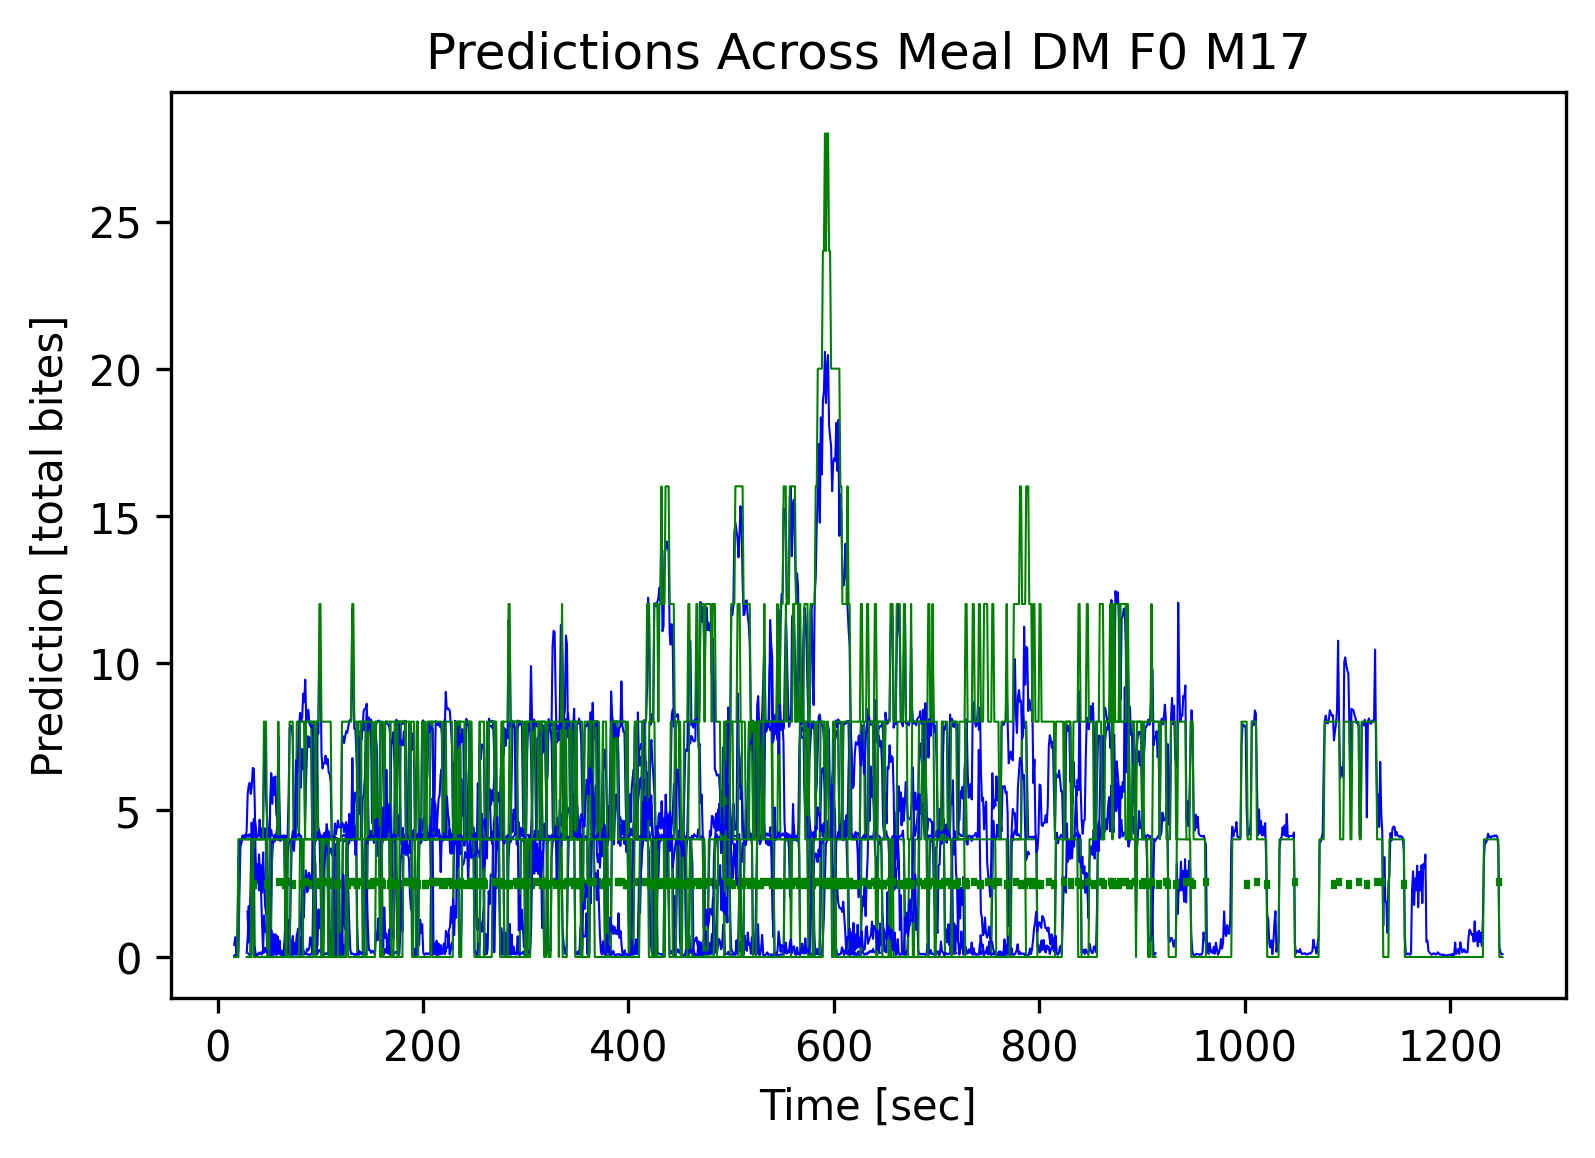

In [9]:
### TOGGLE PLOT COMMANDS TO DETERMINE WHICH MODELS LEARN WELL AND WHICH DON'T

for currMealNum in range(len(SingleMealSelect)):
# for currMealNum in [2]:
	AllPreds = All_AllPreds[currMealNum]
	x_data=All_Timesteps[currMealNum]
	gt_bite_times = All_gt_bite_times[currMealNum]
	GT_Targets = np.ones(np.shape(AllGtTargets[currMealNum]))*(-1)
	for i in range(len(GT_Targets)):
		GT_Targets[i] = AllGtTargets[currMealNum][i]
	# End of copying targets without python making an alias

	AvgPreds = np.ones(len(AllPreds[0]))*(-1)
	for target_idx in range(len(GT_Targets)):
		# scale the GT bites by scale factor
		GT_Targets[target_idx] = SCALE_FACTOR * GT_Targets[target_idx]
		
		Avg_sum=0
		#Compute average predictions
		for i in range(len(AllPreds)):
			Avg_sum+=AllPreds[i][target_idx]
		AvgPreds[target_idx] = Avg_sum/len(AllPreds)
	# end of for target_idx
	
	plt.figure('w',dpi=300)

	# 10 sec fold 1 --> Good = 3, 6, 8; Weird = 5; Bad = 0, 1, 2, 4, 7, 9
	# 10 sec fold 3 --> Good = 0, 1, 3, 5, 7, 8, 9; Weird = 4; Bad = 2, 6

	# plt.plot(x_data,AllPreds[0],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[1],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[2],'c',lw=0.5)
	# plt.plot(x_data,AllPreds[3],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[4],'k',lw=0.5)
	# plt.plot(x_data,AllPreds[5],'b',lw=0.5)
	
	
	plt.plot(x_data,AvgPreds,'b',lw=0.5)
	
	
	# Start Plotting GT
	GT_BaselineY = 2.5
	staggerFlag=0
	for i in range(len(gt_bite_times)):
		if staggerFlag == 0:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY-0.1,GT_BaselineY],'g-')
		elif staggerFlag == 1:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY,GT_BaselineY+0.1],'g-')
		staggerFlag = (staggerFlag+1)%2
	# End of plotting GT
	
	
	plt.plot(x_data,GT_Targets,'g',lw=0.5)
	
	
	
	plt.xlabel('Time [sec]')
	plt.ylabel('Prediction [total bites]')

	plt.title("Predictions Across Meal {} F{} M{}".format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))

	# plt.savefig('AllPreds_OneMeal_M{}.png'.format(SingleMealSelect[currMealNum]))
	# plt.savefig('z_Visualizations/AvgPreds_OneMeal_{}_F{}_M{}.png'.format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))
	# plt.close()
# end of for meal loop
print("Finished with Saving Plots.")

Finished with Saving Plots.


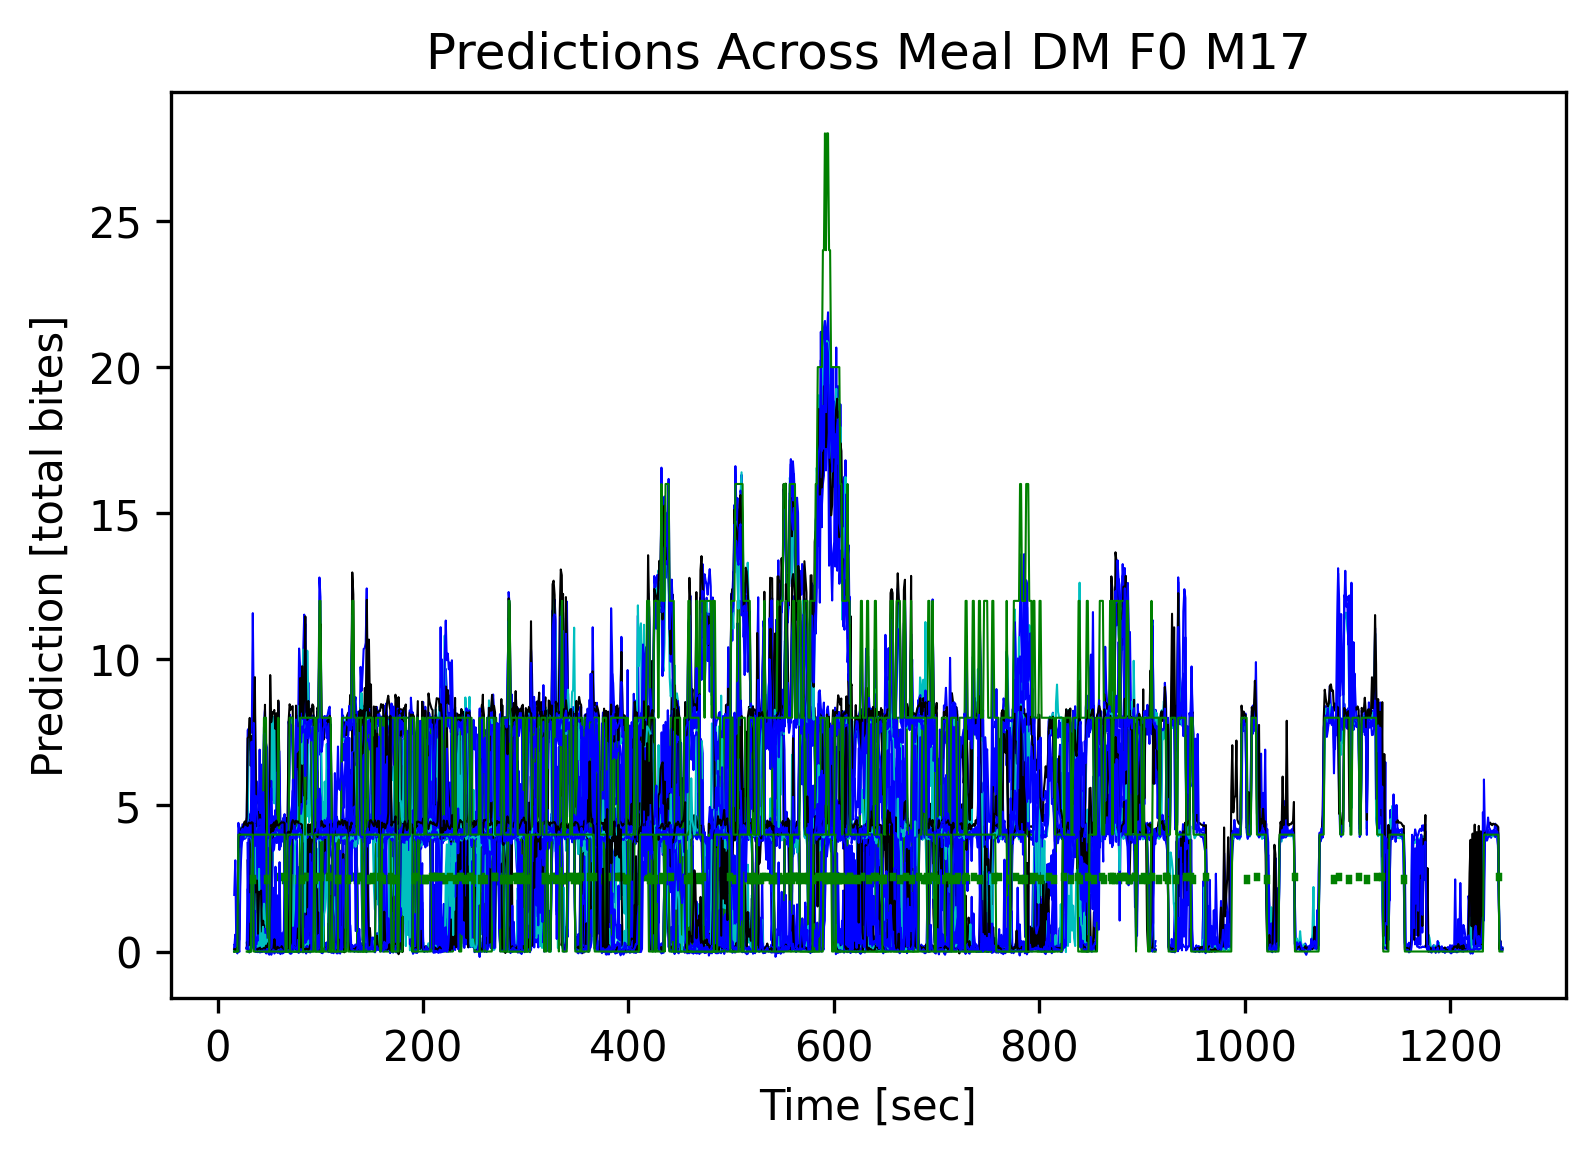

In [10]:
### TOGGLE PLOT COMMANDS TO DETERMINE WHICH MODELS LEARN WELL AND WHICH DON'T

for currMealNum in range(len(SingleMealSelect)):
# for currMealNum in [2]:
	AllPreds = All_AllPreds[currMealNum]
	x_data=All_Timesteps[currMealNum]
	gt_bite_times = All_gt_bite_times[currMealNum]
	
	plt.figure('w',dpi=300)

	# 10 sec fold 1 --> Good = 3, 6, 8; Weird = 5; Bad = 0, 1, 2, 4, 7, 9
	# 10 sec fold 3 --> Good = 0, 1, 3, 5, 7, 8, 9; Weird = 4; Bad = 2, 6

	plt.plot(x_data,AllPreds[0],'b',lw=0.5)
	plt.plot(x_data,AllPreds[1],'b',lw=0.5)
	plt.plot(x_data,AllPreds[2],'c',lw=0.5)
	plt.plot(x_data,AllPreds[3],'b',lw=0.5)
	plt.plot(x_data,AllPreds[4],'k',lw=0.5)
	plt.plot(x_data,AllPreds[5],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[6],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[7],'b',lw=0.5)
	# plt.plot(x_data,AllPreds[8],'r',lw=0.5)
	# plt.plot(x_data,AllPreds[9],'b',lw=0.5)

	
	
	GT_Targets = np.ones(np.shape(AllGtTargets[currMealNum]))*(-1)
	for i in range(len(GT_Targets)):
		GT_Targets[i] = AllGtTargets[currMealNum][i]
	# End of copying targets without python making an alias
	for target_idx in range(len(GT_Targets)):
		# scale the GT bites by scale factor
		GT_Targets[target_idx] = SCALE_FACTOR * GT_Targets[target_idx]
	# end of for target_idx
	plt.plot(x_data,GT_Targets,'g',lw=0.5)

	
	
	# Start Plotting GT
	GT_BaselineY = 2.5
	staggerFlag=0
	for i in range(len(gt_bite_times)):
		if staggerFlag == 0:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY-0.1,GT_BaselineY],'g-')
		elif staggerFlag == 1:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY,GT_BaselineY+0.1],'g-')
		staggerFlag = (staggerFlag+1)%2
	# End of plotting GT
	
	# Start Plotting GT
	GT_BaselineY = 2.5
	staggerFlag=0
	for i in range(len(gt_bite_times)):
		if staggerFlag == 0:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY-0.1,GT_BaselineY],'g-')
		elif staggerFlag == 1:
			plt.plot([gt_bite_times[i],gt_bite_times[i]],[GT_BaselineY,GT_BaselineY+0.1],'g-')
		staggerFlag = (staggerFlag+1)%2
	# End of plotting GT

	plt.xlabel('Time [sec]')
	plt.ylabel('Prediction [total bites]')

	plt.title("Predictions Across Meal {} F{} M{}".format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))

	# plt.savefig('z_Visualizations/AllPreds_OneMeal_{}_F{}_M{}.png'.format(DATABASE_ACRONYM,FOLD_INDEX,SingleMealSelect[currMealNum]))
	# plt.close()
# end of for meal loop
print("Finished with Saving Plots.")